In [1]:
"""
generar_enunciado.py — Evaluación, Programación Científica 2026-1 (UNAL)

Genera el ENUNCIADO personalizado de cada estudiante a partir de su ID.
Los parámetros numéricos son únicos por ID

    python generar_enunciado.py 0784      # <- últimos 4 dígitos de su ID

Produce enunciado_XXXX.md.  (Los datos se generan aparte con generar_datos.py.)
"""
import sys
import numpy as np


def parametros(seed):
    r = np.random.default_rng(seed + 10_000)
    return dict(
        n=int(r.choice([8, 10, 12, 15])),        # señales por régimen
        K=int(r.choice([15, 20, 25, 30])),       # nº de frecuencias de la capa Fourier
        n_iter=int(r.choice([2000, 3000, 4000])),# iteraciones de entrenamiento
        eta=float(r.choice([0.02, 0.05, 0.1])),  # learning rate sugerido
        foco=int(r.choice([0, 1, 2])),           # régimen a analizar en detalle
        energia=int(r.choice([85, 90, 95])),     # umbral de compresión (%)
    )


def enunciado_md(seed, p):
    return f"""# Evaluación 2

**Programación Científica 2026-1 · Universidad Nacional de Colombia** — mbastidaso@unal.edu.co

**Modalidad:** individual · **Entrega:** GitHub (rama + Pull Request)

> ⚙️ **Enunciado personalizado — ID {seed}.** Los parámetros son únicos.

---

## Idea central

Este semestre aproximamos funciones como combinación de bases, $\hat f(t)=\sum_i c_i\phi_i(t)$.

Una **red neuronal** hace lo mismo, pero **aprende** sus propias bases en vez de fijarlas.

En esta evaluación construimos una red que **reconstruye** una señal, y estudiamos qué pasa cuando su **primera capa es la Transformada de Fourier**.

La pregunta que guía todo: *¿ayuda empezar con la base "correcta" (Fourier) en lugar de una base aleatoria?*

---

# Parte I — El fenómeno

## 1. Ondas que se dispersan

En un medio **sin dispersión** todas las frecuencias viajan igual y una onda mantiene su forma. En un medio **dispersivo**, distintas frecuencias viajan a distinta velocidad: es lo que separa los colores en un prisma, deforma un pulso en una fibra óptica, y hace que las olas largas lleguen antes que las cortas. Los datos vienen de un medio dispersivo.

## 2. La regla del medio

Una onda se compone de **modos**, cada uno con un número entero $k$ (su número de onda). La regla asigna a cada modo una **frecuencia** $\omega(k)$:

$$\omega(k) = \sqrt{{c^2 k^2 + \mu^2}}.$$

Esta información es dada: Si $\mu=0$ las frecuencias son bajas; si \$\mu>0$, el término $\mu^2$ **empuja las frecuencias hacia arriba** (mayor $\mu$, oscilaciones más rápidas). El parámetro $\mu$ define **tres regímenes** (las etiquetas `y` de los datos): 0 = sin dispersión (frecuencias bajas), 1 = intermedia, 2 = fuerte (frecuencias altas).

## 3. Lo que medimos

Un sensor fijo registra la suma de los modos en el tiempo:

$$f(t) = \sum_j a_j \cos\bigl(\omega(k_j)\,t + \varphi_j\bigr).$$

**Cada señal es una suma de cosenos a frecuencias bien definidas**, justo lo que una base de senos y cosenos representa con pocos coeficientes.

---

# Parte II — Los datos

Generar los datos con los 4 últimos dígitos del ID (script aparte) y cargarlos.

El conjunto tiene **{p['n']} señales por régimen** ({3*p['n']} en total).

---

# Parte III — La red

Construir, **en JAX**, una red que recibe una señal $x\in\mathbb{{R}}^{{256}}$ y la **reconstruye** (su salida $\hat x$ debe parecerse a $x$).

La red se entrena minimizando el error (media cuadrática) entre la señal original y la reconstruida:

$$\mathcal{{L}} = \tfrac1N\|\hat x - x\|^2$$

## La arquitectura

La red tiene dos capas. La **primera** es una capa lineal de tamaño $256 \to 2K$ (con **K = {p['K']}** frecuencias) seguida de una no linealidad $\tanh$; la **siguiente** es una capa lineal $2K \to 256$ que reconstruye la señal:

$$\hat x = W_2\,\tanh(W_1 x).$$

La idea central está en $W_1$. Sus pesos pueden **inicializarse como la matriz de Fourier**: las filas son $\sin(2\pi k t)$ y $\cos(2\pi k t)$, $k=1,\dots,{p['K']}$ o de forma **aleatoria**. En ambos casos $W_1$ se sigue entrenando: lo único que cambia es el punto de partida.

## Lo que se espera

Este trabajo debe permitir responder, con evidencia propia, si conviene arrancar la red en la base de Fourier en lugar de una base aleatoria. Para ello:

- Construir la capa Fourier y verificar que, en su punto de partida, calcula efectivamente una transformada de Fourier de la señal.
- Entrenar la red con las **dos inicializaciones** (Fourier y aleatoria) sobre señales de los tres regímenes, durante **{p['n_iter']} iteraciones** (learning rate sugerido $\eta={p['eta']}$), y estudiar la evolución de la pérdida (error) en cada caso.
- Prestar especial atención al **régimen {p['foco']}** y a la **velocidad** con que cada inicialización mejora.
- Explorar cuánta información de la señal vive en pocos coeficientes de la capa Fourier (compresión, con referencia al **{p['energia']}%** de la energía).

Las gráficas y resultados concretos que se deben entregar están en la **rúbrica** (documento de instrucciones de la evaluación).


# Entrega por GitHub

1. Rama propia: `git checkout -b eval2-APELLIDOS`
2. Carpeta con los **apellidos** en la raíz del repositorio:
   ```
   PerezGomez/
   ├── solucion.ipynb        # el notebook resuelto, con las 3 respuestas
   ├── enunciado_{seed}.md   # el enunciado personalizado
   └── datos_{seed}.npz      # los datos
   ```
3. **Varios Commits semánticos** (`feat:`, `fix:`, `docs:`, `data:`) no un único commit final.
4. Abre un **Pull Request** con una descripicón corta del trabajo.

> 📊 ** Acumulativo.** Este curso se evalúa de forma acumulativa, siempre debemos dar especial énfasis en visualización científica: ejes con unidades, tipo de gráfico y mapa de color justificados, leyendas claras, figuras que comuniquen una idea. Una reconstrucción correcta en una figura pobre no recibe puntaje completo.
"""

# The original `if __name__ == "__main__":` block is designed for command-line execution.
# In a Colab notebook, we can directly call the functions with the desired seed.
seed = 784 # Set the seed directly
p = parametros(seed)
with open(f"enunciado_{seed}.md", "w", encoding="utf-8") as f:
    f.write(enunciado_md(seed, p))
print(f"Enunciado generado para cédula {seed}: enunciado_{seed}.md")
print(f"Los parámetros: K={p['K']}, iteraciones={p['n_iter']}, \u03b7={p['eta']}, "
      f"n={p['n']}/régimen, régimen foco={p['foco']}, compresión {p['energia']}%")


Enunciado generado para cédula 784: enunciado_784.md
Los parámetros: K=30, iteraciones=2000, η=0.02, n=12/régimen, régimen foco=2, compresión 85%


<>:130: SyntaxWarning: invalid escape sequence '\h'
<>:124: SyntaxWarning: invalid escape sequence '\m'
<>:126: SyntaxWarning: invalid escape sequence '\m'
<>:130: SyntaxWarning: invalid escape sequence '\i'
<>:124: SyntaxWarning: invalid escape sequence '\h'
<>:124: SyntaxWarning: invalid escape sequence '\|'
<>:126: SyntaxWarning: invalid escape sequence '\h'
<>:124: SyntaxWarning: invalid escape sequence '\e'
<>:130: SyntaxWarning: invalid escape sequence '\h'
<>:124: SyntaxWarning: invalid escape sequence '\m'
<>:126: SyntaxWarning: invalid escape sequence '\m'
<>:130: SyntaxWarning: invalid escape sequence '\i'
<>:124: SyntaxWarning: invalid escape sequence '\h'
<>:124: SyntaxWarning: invalid escape sequence '\|'
<>:126: SyntaxWarning: invalid escape sequence '\h'
<>:124: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_5296/3553472301.py:130: SyntaxWarning: invalid escape sequence '\h'
  with open(f"enunciado_{seed}.md", "w", encoding="utf-8") as f:
/tmp/ipykernel_5296/

In [2]:
"""
generar_datos.py — Evaluación 2, Programación Científica 2026-1 (UNAL)

Genera el conjunto de señales ÚNICO de cada estudiante a partir de su cédula.

    python generar_datos.py 4815      # <- últimos 4 dígitos de su cédula

Produce datos_XXXX.npz con:
    X : (n, 256)  señales medidas
    y : (n,)      régimen de cada señal (0, 1, 2)
    t : (256,)    instantes de muestreo

El número de señales por régimen lo fija el enunciado personalizado
(generar_enunciado.py). Por defecto son 12 por régimen.
"""
import sys
import getpass
import socket
import hashlib
import datetime
import numpy as np


def n_por_regimen(seed):
    # mismo criterio que generar_enunciado.py: parámetro derivado de la cédula
    return int(np.random.default_rng(seed + 10_000).choice([8, 10, 12, 15]))


def _huella():
    try:
        crudo = f"{getpass.getuser()}@{socket.gethostname()}"
    except Exception:
        crudo = "desconocido"
    return hashlib.sha256(crudo.encode()).hexdigest()[:16]


def generar(seed, n=None):
    if n is None:
        n = n_por_regimen(seed)
    r = np.random.default_rng(seed)
    _n = 256
    _t = np.linspace(0, 1, _n, endpoint=False)
    _v = 1.0
    _s = r.uniform(0.2, 0.6)
    _w = lambda kk, mm: np.sqrt((_v * kk) ** 2 + mm ** 2)

    def _mk(mm):
        _k = r.choice(np.arange(1, 12), size=3, replace=False)
        _a = r.uniform(0.3, 1.0, 3)
        _p = r.uniform(0, 2 * np.pi, 3)
        _u = np.zeros_like(_t)
        for _ki, _ai, _pi in zip(_k, _a, _p):
            _u += _ai * np.cos(_w(_ki, mm) * 2 * np.pi * _t - _ki * _s + _pi)
        return _u

    _X, _y = [], []
    for _lab, _mm in {0: 0.0, 1: 5.0, 2: 15.0}.items():
        for _ in range(n):
            _X.append(_mk(_mm) + r.normal(0, 0.02, _n))
            _y.append(_lab)
    _X, _y = np.array(_X), np.array(_y)
    _perm = r.permutation(len(_y))
    return _X[_perm], _y[_perm], _t


# The original `if __name__ == '__main__':` block is designed for command-line execution.
# In a Colab notebook, we can directly call the functions with the desired seed.
seed = 784 # Set the seed directly
X, y, t = generar(seed)
meta = np.array([str(seed), _huella(),
                 datetime.datetime.now().isoformat(timespec="seconds")])
np.savez(f"datos_{seed}.npz", X=X, y=y, t=t, meta=meta)
print(f"Datos generados para cédula {seed}: X={X.shape}, y={y.shape}, t={t.shape}")
print(f"Guardado en datos_{seed}.npz")

Datos generados para cédula 784: X=(36, 256), y=(36,), t=(256,)
Guardado en datos_784.npz


[0 2 1 1 0 2 0 0 1 1 0 0 0 2 2 2 2 2 1 0 1 2 2 0 1 1 1 2 2 0 2 0 1 1 1 0]


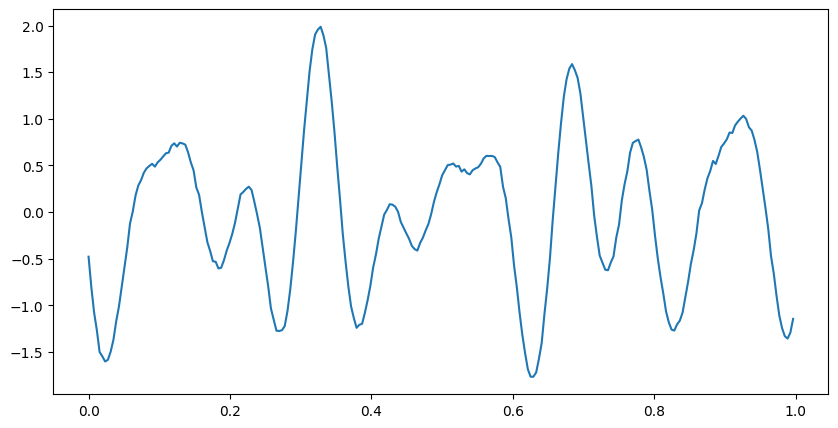

In [18]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# 1. Carga de datos
datos = np.load('datos_784.npz') # Asegúrate de que este archivo esté en tu carpeta
X = jnp.array(datos['X'])
y = jnp.array(datos['y'])
t = jnp.array(datos['t'])

K = 30 # Número de frecuencias dadas en el enunciado
#print(y)
#plt.figure(figsize=(10,5))
#plt.plot(t,X[2])
#plt.show()

In [21]:


# Neural network model
def model(W1, W2, x):
    # x es (256,)
    # W1 es (2K, 256)
    # W2 es (256, 2K)
    hidden = jnp.tanh(jnp.dot(W1, x))
    output = jnp.dot(W2, hidden)
    return output

# función de pérdida (Error medio cuádractico)
def loss_fn(W1, W2, X_batch):
    # X_batch is (batch_size, 256)
    predictions = jax.vmap(model, in_axes=(None, None, 0))(W1, W2, X_batch)
    return jnp.mean(jnp.square(predictions - X_batch))

# Función de actualización para el gradiente descendente
@jax.jit
def update(W1, W2, X_batch, lr):
    loss, grads = jax.value_and_grad(loss_fn, argnums=(0, 1))(W1, W2, X_batch)
    W1_grad, W2_grad = grads
    W1 -= lr * W1_grad
    W2 -= lr * W2_grad
    return W1, W2, loss

# Función de inicialización de parametros (Random)
def init_random_params(key):
    key, subkey1, subkey2 = jax.random.split(key, 3)
    # W1: 256 -> 2K
    W1 = jax.random.normal(subkey1, (2 * K, 256)) * 0.01 # Pesos aleatorios pequeños
    # W2: 2K -> 256
    W2 = jax.random.normal(subkey2, (256, 2 * K)) * 0.01
    return W1, W2

# Función de inicialización de parametros (Parameter initialization function) (Fourier)
def init_fourier_params(key, t_vals):
    key, subkey = jax.random.split(key)
    # W1: Base de Fourier
    # Las filas son sin(2*pi*k*t) y cos(2*pi*k*t) for k=1...K
    fourier_rows = []
    for k_val in range(1, K + 1):
        fourier_rows.append(jnp.sin(2 * jnp.pi * k_val * t_vals))
        fourier_rows.append(jnp.cos(2 * jnp.pi * k_val * t_vals))
    W1_fourier = jnp.array(fourier_rows)

    # W2: Inicialización aleatoria para la segunda capa
    W2_random = jax.random.normal(subkey, (256, 2 * K)) * 0.01
    return W1_fourier, W2_random


def train_network(W1, W2, X_train, iterations=2000, lr=0.02):
    losses = []
    for i in range(iterations):
        W1, W2, loss = update(W1, W2, X_train, lr)
        losses.append(loss)
    return W1, W2, losses



key = jax.random.PRNGKey(784)

# Entrenamiento Aleatorio
W1_rand, W2_rand = init_random_params(key)
W1_rand_opt, W2_rand_opt, losses_rand = train_network(W1_rand, W2_rand, X, lr=0.02)

# Entrenamiento Fourier
W1_four, W2_four = init_fourier_params(key, t)
W1_four_opt, W2_four_opt, losses_four = train_network(W1_four, W2_four, X, lr=0.02)



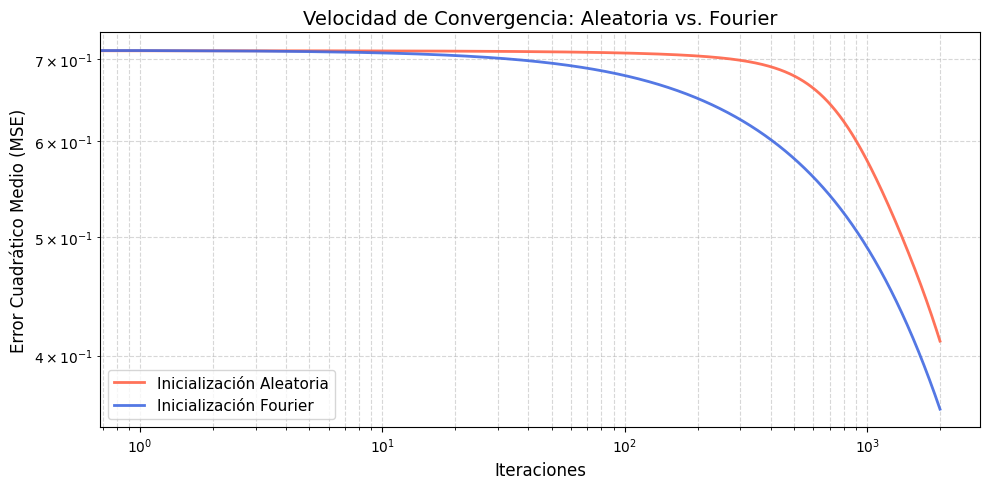

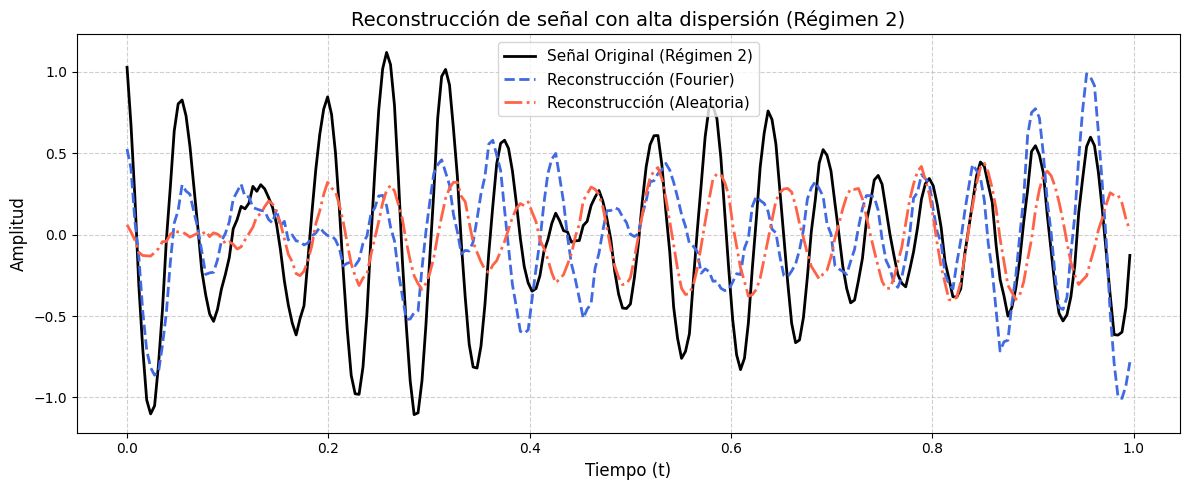

In [20]:
# === VISUALIZACIÓN DE RESULTADOS === (Regímen 2)
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
# 1. Análisis de la velocidad de convergencia (Función de pérdida)
plt.figure(figsize=(10, 5))
# Graficamos ambas listas de pérdidas obtenidas en tu código
plt.loglog(losses_rand, label='Inicialización Aleatoria', color='tomato', alpha=0.9, linewidth=2)
plt.loglog(losses_four, label='Inicialización Fourier', color='royalblue', alpha=0.9, linewidth=2)

plt.title('Velocidad de Convergencia: Aleatoria vs. Fourier', fontsize=14)
plt.xlabel('Iteraciones', fontsize=12)
plt.ylabel('Error Cuadrático Medio (MSE)', fontsize=12)
#plt.yscale('log') # Usamos escala logarítmica para apreciar mejor la caída inicial del error
plt.legend(fontsize=11)
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2. Análisis de Reconstrucción (Enfocado en el Régimen 2)
# Buscamos el índice de la primera señal que pertenezca al régimen 2
indice_regimen_2 = jnp.where(y == 2)[0][0]
senal_original = X[indice_regimen_2]

# Generamos las predicciones usando los pesos optimizados de tu código
pred_rand = model(W1_rand_opt, W2_rand_opt, senal_original)
pred_four = model(W1_four_opt, W2_four_opt, senal_original)

plt.figure(figsize=(12, 5))
plt.plot(t, senal_original, label='Señal Original (Régimen 2)', color='black', linewidth=2)
plt.plot(t, pred_four, label='Reconstrucción (Fourier)', color='royalblue', linestyle='--', linewidth=2)
plt.plot(t, pred_rand, label='Reconstrucción (Aleatoria)', color='tomato', linestyle='-.', linewidth=2)

plt.title('Reconstrucción de señal con alta dispersión (Régimen 2)', fontsize=14)
plt.xlabel('Tiempo (t)', fontsize=12)
plt.ylabel('Amplitud', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

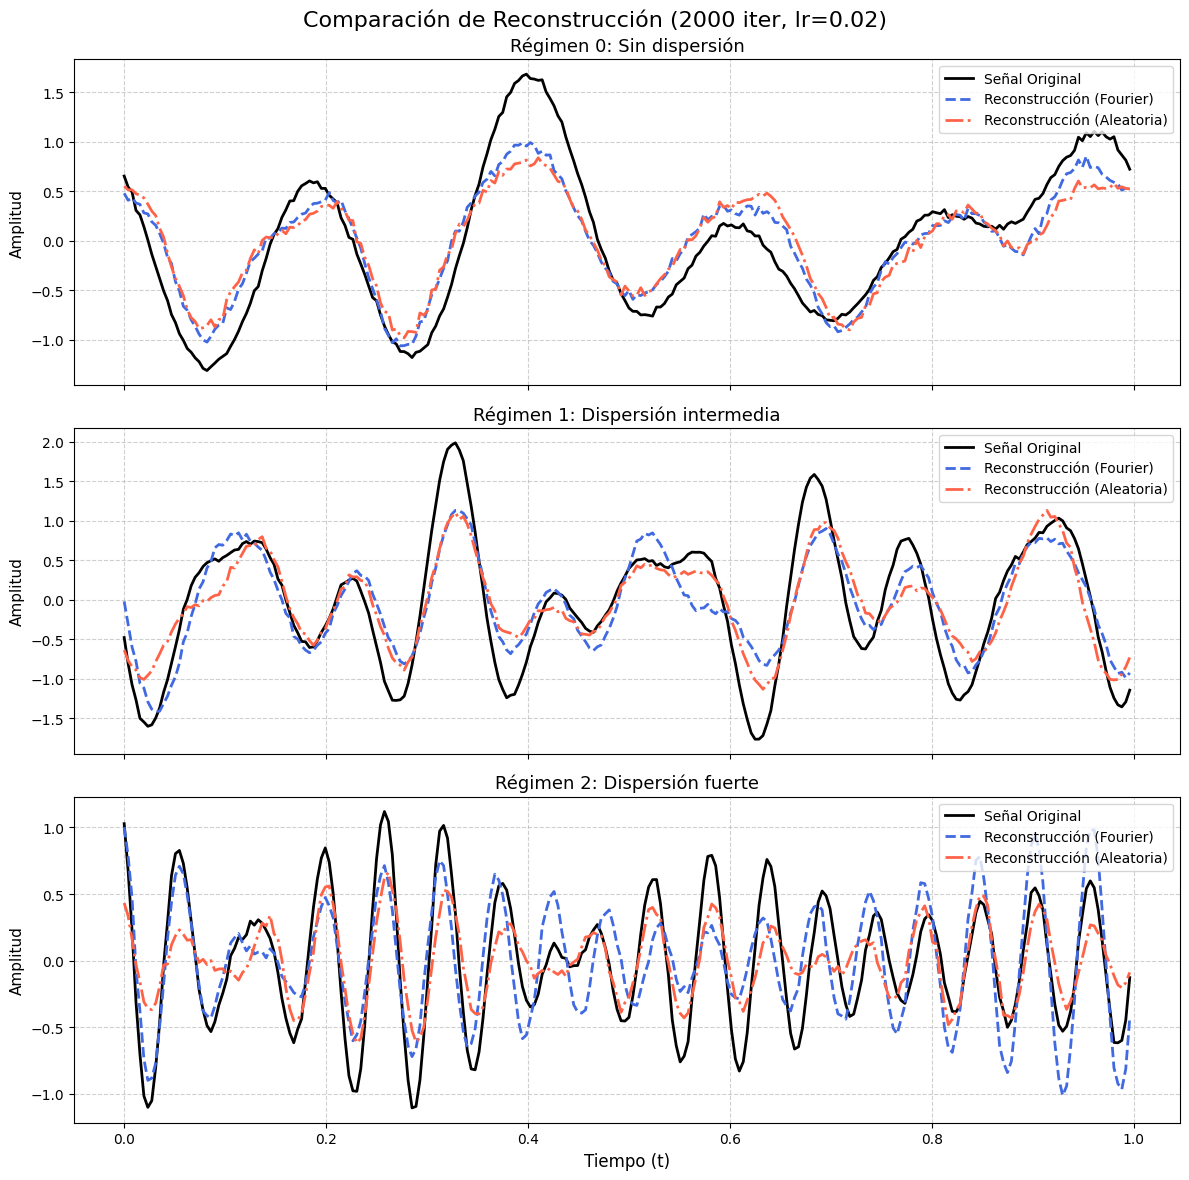

In [7]:
# === RECONSTRUCCIÓN DE SEÑALES (PARÁMETROS ORIGINALES) ===

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
regimenes = [0, 1, 2]
nombres_reg = ['Sin dispersión', 'Dispersión intermedia', 'Dispersión fuerte']

for reg in regimenes:
    X_reg = X[y == reg]
    senal_original = X_reg[0]

    W1_r, W2_r = init_random_params(key)
    W1_f, W2_f = init_fourier_params(key, t)

    # CAMBIO CLAVE: Volvemos a 2000 iteraciones y lr=0.02 según el enunciado
    iteraciones_enunciado = 2000
    lr_enunciado = 0.02

    W1_r_opt, W2_r_opt, _ = train_network(W1_r, W2_r, X_reg, iterations=iteraciones_enunciado, lr=lr_enunciado)
    W1_f_opt, W2_f_opt, _ = train_network(W1_f, W2_f, X_reg, iterations=iteraciones_enunciado, lr=lr_enunciado)

    pred_rand = model(W1_r_opt, W2_r_opt, senal_original)
    pred_four = model(W1_f_opt, W2_f_opt, senal_original)

    ax = axes[reg]
    ax.plot(t, senal_original, label='Señal Original', color='black', linewidth=2)
    ax.plot(t, pred_four, label='Reconstrucción (Fourier)', color='royalblue', linestyle='--', linewidth=2)
    ax.plot(t, pred_rand, label='Reconstrucción (Aleatoria)', color='tomato', linestyle='-.', linewidth=2)

    ax.set_title(f'Régimen {reg}: {nombres_reg[reg]}', fontsize=13)
    ax.set_ylabel('Amplitud', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper right', fontsize=10)

axes[-1].set_xlabel('Tiempo (t)', fontsize=12)
plt.suptitle('Comparación de Reconstrucción (2000 iter, lr=0.02)', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()